In [ ]:
# import necessary libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, roc_auc_score, classification_report, 
    confusion_matrix
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [4]:
# Define the path to the CSV file
CSV_PATH = "data/creditcard.csv"
TARGET_COLUMN = "Class"
USE_SMOTE = True 
USE_SYNTHETIC_PLACEHOLDER = True


In [9]:
def load_data():
    if not USE_SYNTHETIC_PLACEHOLDER:
        # Load the dataset
        df = pd.read_csv(CSV_PATH)
        X = df.drop(columns=[TARGET_COLUMN])
        y = df[TARGET_COLUMN]
        return X, y
    
# placeholder for synthetic data generation
    from sklearn.datasets import make_classification
    X_arr, y_arr = make_classification(n_samples=5000, 
                                       n_features=10, 
                                       n_informative=6, 
                                       n_redundant=2, 
                                       weights=[0.99, 0.01], 
                                       flip_y=0.01, 
                                       random_state=42
                                       )
    X = pd.DataFrame(X_arr, columns=[f'feature_{i}' for i in range(X_arr.shape[1])])
    y = pd.Series(y_arr, name=TARGET_COLUMN)
    return X, y


X, y = load_data()

print(f"Rows: {X.shape[0]}, Features: {X.shape[1]}")
print("Class balance: ")
print(y.value_counts())
print(f"Fraud rate: {y.mean() * 100:.3f}%")


Rows: 5000, Features: 10
Class balance: 
Class
0    4924
1      76
Name: count, dtype: int64
Fraud rate: 1.520%


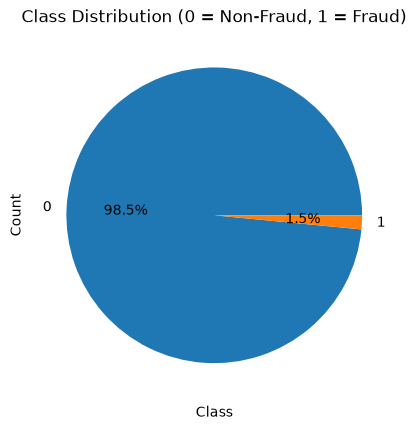

In [ ]:
# Visualize class distribution

import matplotlib.pyplot as plt

y.value_counts().plot(kind='pie', title='Class Distribution (0 = Non-Fraud, 1 = Fraud)', autopct='%1.1f%%')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [21]:
#train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} rows (fraud rate: {y_train.mean() * 100:.3f}%)")
print(f"Testing set: {X_test.shape[0]} rows (fraud rate: {y_test.mean() * 100:.3f})%")

Training set: 4000 rows (fraud rate: 1.525%)
Testing set: 1000 rows (fraud rate: 1.500)%


In [22]:
#building the pipeline

log_reg_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

random_forest_pipeline = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [24]:
# tune hyperparameters for logistic regression
log_reg_param_grid = {
    'classifier__C': [0.1, 1, 10],
}

random_forest_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None]
}

print("Tuning hyperparameters for Logistic Regression...")
log_reg_search = GridSearchCV(log_reg_pipeline, log_reg_param_grid, cv=5, scoring='roc_auc', n_jobs=-1)

log_reg_search.fit(X_train, y_train)

print(f"Best parameters for Logistic Regression: {log_reg_search.best_params_}")
print(f"Best ROC AUC for Logistic Regression: {log_reg_search.best_score_:.4f}")

Tuning hyperparameters for Logistic Regression...
Best parameters for Logistic Regression: {'classifier__C': 0.1}
Best ROC AUC for Logistic Regression: 0.6717


In [25]:
print("Tuning hyperparameters for Random Forest...")
random_forest_search = GridSearchCV(random_forest_pipeline, random_forest_param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
random_forest_search.fit(X_train, y_train)

print(f"Best parameters for Random Forest: {random_forest_search.best_params_}")
print(f"Best ROC AUC for Random Forest: {random_forest_search.best_score_:.4f}")

Tuning hyperparameters for Random Forest...
Best parameters for Random Forest: {'classifier__max_depth': None, 'classifier__n_estimators': 100}
Best ROC AUC for Random Forest: 0.7141


In [39]:
# evaluate the best models on the test set

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    print(f"---{name}---")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print("\nConfusion Matrix (rows=actual, columns=predicted):")
    print(confusion_matrix(y_test, y_pred))
    print("\n Full Classification Report:")
    print(classification_report(y_test, y_pred, target_names=["Non-Fraud", "Fraud"]))
    print()

    return {"model": name, "precision": precision, "recall": recall, "roc_auc": roc_auc}


results = []
results.append(evaluate_model("Logistic Regression", log_reg_search.best_estimator_, X_test, y_test))
results.append(evaluate_model("Random Forest", random_forest_search.best_estimator_, X_test, y_test))

---Logistic Regression---
Precision: 0.0318
Recall: 0.6667
ROC AUC: 0.7262

Confusion Matrix (rows=actual, columns=predicted):
[[681 304]
 [  5  10]]

 Full Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.69      0.82       985
       Fraud       0.03      0.67      0.06        15

    accuracy                           0.69      1000
   macro avg       0.51      0.68      0.44      1000
weighted avg       0.98      0.69      0.80      1000


---Random Forest---
Precision: 0.1875
Recall: 0.2000
ROC AUC: 0.8324

Confusion Matrix (rows=actual, columns=predicted):
[[972  13]
 [ 12   3]]

 Full Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.99      0.99       985
       Fraud       0.19      0.20      0.19        15

    accuracy                           0.97      1000
   macro avg       0.59      0.59      0.59      1000
weighted avg       0.98      0.97      0.98   

In [40]:
# model comparison
comparison_df = pd.DataFrame(results)
comparison_df

,model,precision,recall,roc_auc
0,Logistic Regression,0.031847,0.666667,0.726227
1,Random Forest,0.187500,0.200000,0.832420


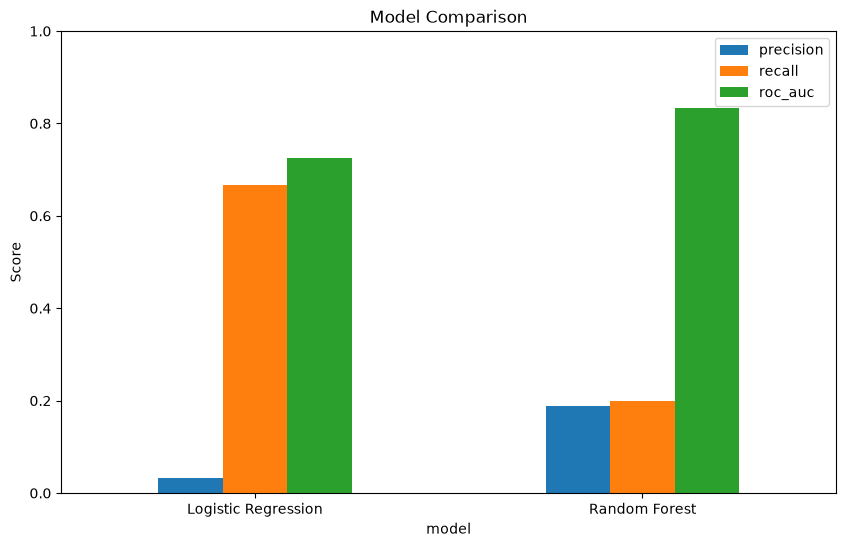

In [43]:
comparison_df.plot(kind='bar', x='model', y=['precision', 'recall', 'roc_auc'], title='Model Comparison', figsize=(10, 6))
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()
